<div style="text-align: center; padding: 30px 0;">

# 🎓 Learning Behavior Clustering and Student Profiling
## Phase 1 — Data Collection & Preprocessing


</div>




---
## 1. Introduction

This notebook covers **Phase 1** of the *Learning Behavior Clustering and Student Profiling* project: **Data Collection and Preprocessing**.

### Project Context

The overarching goal of this project is to build an end-to-end unsupervised machine learning system that identifies meaningful learning behavior profiles among university students. By clustering students into groups such as *high performers*, *last-minute learners*, or *struggling students*, the system aims to:

- Provide early identification of at-risk students.
- Support evidence-based teaching strategies.
- Enable personalized academic advising.



---
## 2. Dataset Description & Feature Dictionary

The dataset contains **anonymized academic and behavioral records** of university students. Each row represents one student observation. All personally identifiable information has been removed prior to collection.

### Dataset at a Glance

| Property | Value |
|----------|-------|
| **Source** | Anonymized institutional academic records |
| **Format** | CSV (comma-separated values) |
| **Total Rows (raw)** | 14,003 |
| **Total Features** | 16 |
| **Target Variable** | `FinalGrade` |

---

### 📖 Feature Dictionary

#### 🏫 Academic Performance Features

| Feature | Type | Values / Range | Description & Importance |
|---------|------|----------------|--------------------------|
| `ExamScore` | Numerical | 0–100 | The student's score on their main exam. A direct measure of academic achievement and a key signal for clustering performance levels. |
| `AssignmentCompletion` | Numerical | 0–100 | Percentage of assignments submitted. Reflects consistency and responsibility — a strong behavioral predictor. |
| `FinalGrade` | Ordinal (encoded) | 0, 1, 2, 3 | The student's final grade category: **0 = F**, **1 = C**, **2 = B**, **3 = A**. Used as a reference label and for validation. |

#### 📚 Study Habits & Engagement Features

| Feature | Type | Values / Range | Description & Importance |
|---------|------|----------------|--------------------------|
| `StudyHours` | Numerical | 5–44 hrs/week | Weekly time dedicated to studying. Strongly linked to performance and a discriminating feature for clustering. |
| `Attendance` | Numerical | 60–100 % | Percentage of classes attended. Captures physical engagement; low attendance is an early at-risk signal. |
| `OnlineCourses` | Numerical | 0–30+ | Number of online courses accessed or completed. Reflects self-directed learning behavior. |
| `Discussions` | Binary | 0 = No, 1 = Yes | Whether the student actively participates in class or forum discussions. Indicates collaborative engagement. |
| `Extracurricular` | Binary | 0 = No, 1 = Yes | Participation in extracurricular activities. Provides context on student lifestyle and time allocation. |

#### 🧠 Psychological & Motivational Features

| Feature | Type | Values / Range | Description & Importance |
|---------|------|----------------|--------------------------|
| `Motivation` | Ordinal (encoded) | 0 = Low, 1 = Medium, 2 = High | Self-reported motivation level. Highly relevant for distinguishing engaged vs. disengaged student profiles. |
| `StressLevel` | Ordinal (encoded) | 0 = Low, 1 = Medium, 2 = High | Self-reported academic stress level. Helps identify struggling students who may need support. |

#### 👤 Demographic & Background Features

| Feature | Type | Values / Range | Description & Importance |
|---------|------|----------------|--------------------------|
| `Gender` | Binary (encoded) | 0 = Female, 1 = Male | Student's gender. Included for demographic analysis and fairness monitoring. |
| `Age` | Numerical | 17–30+ | Student's age in years. Provides context; non-traditional students may show distinct behavior patterns. |
| `LearningStyle` | Categorical (encoded) | 0, 1, 2, 3 | Preferred learning modality: **0 = Visual**, **1 = Auditory**, **2 = Reading/Writing**, **3 = Kinesthetic**. Can explain behavioral differences. |

#### 💻 Resource Access & Technology Features

| Feature | Type | Values / Range | Description & Importance |
|---------|------|----------------|--------------------------|
| `Internet` | Binary | 0 = No, 1 = Yes | Whether the student has reliable internet access at home. Affects ability to use digital resources. |
| `Resources` | Binary | 0 = No, 1 = Yes | Access to academic resources (library, materials, tools). Impacts performance and engagement. |
| `EduTech` | Binary | 0 = No, 1 = Yes | Whether the student uses educational technology tools (e.g., LMS, e-books, apps). Reflects technological engagement. |

---


---
## 3. Environment Setup & Required Libraries



In [19]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
from pathlib import Path

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats          # used for outlier detection (IQR / Z-score)

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn (normalization) ───────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")          # Suppress non-critical warnings
pd.set_option("display.max_columns", 50)   # Show all columns
pd.set_option("display.float_format", "{:.2f}".format)

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("✅ All libraries imported successfully.")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

✅ All libraries imported successfully.
   pandas  2.3.3
   numpy   2.3.3


---
## 4. Data Collection Process

### 4.1 Data Source

The dataset (`merged_dataset.csv`) was produced by **merging multiple anonymized institutional data sources**:

| Source | Content |
|--------|---------|
| Academic records system | Grades, exam scores, assignment completion |
| Attendance management system | Weekly and cumulative attendance logs |
| Student surveys | Self-reported motivation, stress, learning style, resource access |
| LMS (Learning Management System) | Online course enrollment, discussion participation, EduTech usage |

The merging was performed on a common anonymized student ID (not present in the final file), and only students with records across **all sources** were retained.

### 4.2 Privacy & Ethics

- All data is **fully anonymized**: no names, IDs, emails, or any personally identifiable information are present.
- Data collection complies with institutional data governance policies.
- The dataset is used exclusively for academic research purposes within this project.







In [20]:
# ── File paths ────────────────────────────────────────────────────────────────
RAW_DATA_PATH       = Path("../Data/raw/merged_dataset.csv")
PROCESSED_DATA_PATH = Path("../Data/processed/cleaned_dataset.csv")

# Ensure processed directory exists
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── Load the raw dataset ──────────────────────────────────────────────────────
df_raw = pd.read_csv(RAW_DATA_PATH)

print(f"✅ Dataset loaded successfully.")
print(f"   Path  : {RAW_DATA_PATH}")
print(f"   Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

✅ Dataset loaded successfully.
   Path  : ..\Data\raw\merged_dataset.csv
   Shape : 14,003 rows × 16 columns


---
## 5. Initial Data Inspection

Before any cleaning, we perform a structured inspection of the raw dataset to understand:
- Its **dimensions** (rows and columns)
- **Data types** of each column
- **First and last rows** to verify correct loading
- **Basic statistics** to spot obvious anomalies

This step establishes a baseline and informs all subsequent cleaning decisions.

In [21]:
# ── Shape ─────────────────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Dataset Dimensions: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("=" * 55)

# ── Data types ────────────────────────────────────────────────────────────────
print("\n📌 Column Names & Data Types:")
print(df_raw.dtypes.to_string())

# ── First 5 rows ──────────────────────────────────────────────────────────────
print("\n📌 First 5 rows (raw):")
df_raw.head()

  Dataset Dimensions: 14,003 rows × 16 columns

📌 Column Names & Data Types:
StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech                 int64
StressLevel             int64
FinalGrade              int64

📌 First 5 rows (raw):


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


---
## 6. Data Cleaning & Preprocessing

We work on a **copy** of the raw dataframe throughout this section to preserve the original data intact. Each sub-section targets a specific type of quality issue.

In [22]:
# ── Work on a copy to preserve the original ───────────────────────────────────
df = df_raw.copy()
print(f"✅ Working copy created. Shape: {df.shape}")

✅ Working copy created. Shape: (14003, 16)


### 6.1 Handling Missing Values

Missing values can arise from merge failures, system outages, or students who did not complete surveys. We first **quantify** the missingness, then apply an appropriate strategy:

- **Numerical columns** → impute with the **median** (robust to outliers)
- **Categorical / encoded columns** → impute with the **mode** (most frequent value)

If a column has more than **40% missing values**, it is considered unreliable and flagged for removal.

In [23]:
# ── Audit: count and percentage of missing values per column ──────────────────
missing_count  = df.isnull().sum()
missing_pct    = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count"  : missing_count,
    "Missing %"      : missing_pct,
    "Action"         : ["None needed" if p == 0
                        else "Drop column" if p > 40
                        else "Impute"
                        for p in missing_pct]
})

print("📌 Missing Value Report:")
print(missing_report[missing_report["Missing Count"] > 0].to_string()
      if missing_report["Missing Count"].sum() > 0
      else "   ✅ No missing values detected in the raw dataset.")

📌 Missing Value Report:
   ✅ No missing values detected in the raw dataset.


In [24]:
# ── Separate column types for targeted imputation ─────────────────────────────
CATEGORICAL_COLS = [
    "Gender", "LearningStyle", "Internet", "EduTech",
    "Extracurricular", "Discussions", "Motivation",
    "StressLevel", "FinalGrade"
]
NUMERICAL_COLS = [c for c in df.columns if c not in CATEGORICAL_COLS]

# ── Drop columns with >40% missing (flag for removal) ─────────────────────────
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"⚠️  Dropped columns with >40% missing: {cols_to_drop}")
else:
    print("✅ No columns exceed the 40% missing threshold.")

# ── Impute numerical columns with median ──────────────────────────────────────
for col in NUMERICAL_COLS:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   [Numerical] '{col}' → imputed with median = {median_val:.2f}")

# ── Impute categorical columns with mode ──────────────────────────────────────
for col in CATEGORICAL_COLS:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"   [Categorical] '{col}' → imputed with mode = {mode_val}")

# ── Verify no missing values remain ──────────────────────────────────────────
remaining = df.isnull().sum().sum()
print(f"\n✅ Missing value handling complete. Remaining nulls: {remaining}")

✅ No columns exceed the 40% missing threshold.

✅ Missing value handling complete. Remaining nulls: 0


### 6.2 Removing Duplicates

Duplicate rows can occur when data from multiple systems is merged on overlapping exports or when the same student appears in more than one data pull. We identify and remove exact full-row duplicates, keeping the **first occurrence**.

In [25]:
# ── Detect duplicates ─────────────────────────────────────────────────────────
n_duplicates = df.duplicated().sum()
n_before     = len(df)

print(f"📌 Duplicate rows detected : {n_duplicates:,} ({n_duplicates / n_before * 100:.2f}% of dataset)")

# ── Remove duplicates ─────────────────────────────────────────────────────────
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

n_after = len(df)
print(f"✅ Duplicates removed.")
print(f"   Before : {n_before:,} rows")
print(f"   After  : {n_after:,} rows")
print(f"   Removed: {n_before - n_after:,} rows")

📌 Duplicate rows detected : 1,534 (10.95% of dataset)
✅ Duplicates removed.
   Before : 14,003 rows
   After  : 12,469 rows
   Removed: 1,534 rows


### 6.3 Outlier Detection & Handling

Outliers are extreme values that can distort clustering results. We use the **IQR method** to detect them:

- Compute Q1 (25th percentile) and Q3 (75th percentile) for each numerical column.
- Any value below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR` is flagged.
- Flagged values are **clipped** (capped) to the nearest valid boundary — this keeps the row in the dataset while removing the distortion.

> **Why clip instead of delete?**  
> Deleting rows risks losing too much data. Clipping keeps all students in the dataset but limits extreme values so they don't dominate the clustering.


In [26]:
# ── Define valid ranges ───────────────────────────────────────────────────────
VALID_RANGES = {
    "StudyHours"          : (1, 168),
    "Attendance"          : (0, 100),
    "AssignmentCompletion": (0, 100),
    "ExamScore"           : (0, 100),
    "Age"                 : (15, 60),
    "OnlineCourses"       : (0, 100),
}

print("📌 Out-of-Range Value Audit:")
any_invalid = False
for col, (lo, hi) in VALID_RANGES.items():
    if col not in df.columns:
        continue
    col_num = pd.to_numeric(df[col], errors="coerce")
    mask    = (col_num < lo) | (col_num > hi)
    n_bad   = mask.sum()
    if n_bad > 0:
        any_invalid = True
        print(f"   ⚠️  '{col}': {n_bad} out-of-range values (expected [{lo}, {hi}])")
        # Clip to valid range
        df[col] = col_num.clip(lo, hi).astype("int32")
        print(f"       → Clipped to [{lo}, {hi}]")
    else:
        print(f"   ✅ '{col}': all values in range [{lo}, {hi}]")

if not any_invalid:
    print("\n✅ All numerical columns are within expected ranges.")

📌 Out-of-Range Value Audit:
   ✅ 'StudyHours': all values in range [1, 168]
   ✅ 'Attendance': all values in range [0, 100]
   ✅ 'AssignmentCompletion': all values in range [0, 100]
   ✅ 'ExamScore': all values in range [0, 100]
   ✅ 'Age': all values in range [15, 60]
   ✅ 'OnlineCourses': all values in range [0, 100]

✅ All numerical columns are within expected ranges.


In [27]:
# ── IQR-based outlier clipping ────────────────────────────────────────────────
# Only apply to continuous numerical columns (not binary/encoded categories)
CONTINUOUS_COLS = ["StudyHours", "Attendance", "AssignmentCompletion",
                   "ExamScore", "Age", "OnlineCourses"]

print("📌 Outlier Report (IQR method):")
any_outliers = False

for col in CONTINUOUS_COLS:
    if col not in df.columns:
        continue
    series = pd.to_numeric(df[col], errors="coerce")
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    if n_out > 0:
        any_outliers = True
        print(f"   ⚠️  '{col}': {n_out} outlier(s) → clipped to [{lower:.1f}, {upper:.1f}]")
        df[col] = series.clip(lower, upper)
    else:
        print(f"   ✅ '{col}': no outliers detected")

if not any_outliers:
    print("\n✅ No outliers found in any continuous column.")
else:
    print(f"\n✅ Outlier clipping complete. Dataset shape: {df.shape}")

📌 Outlier Report (IQR method):
   ⚠️  'StudyHours': 45 outlier(s) → clipped to [4.0, 36.0]
   ✅ 'Attendance': no outliers detected
   ✅ 'AssignmentCompletion': no outliers detected
   ✅ 'ExamScore': no outliers detected
   ✅ 'Age': no outliers detected
   ✅ 'OnlineCourses': no outliers detected

✅ Outlier clipping complete. Dataset shape: (12469, 16)


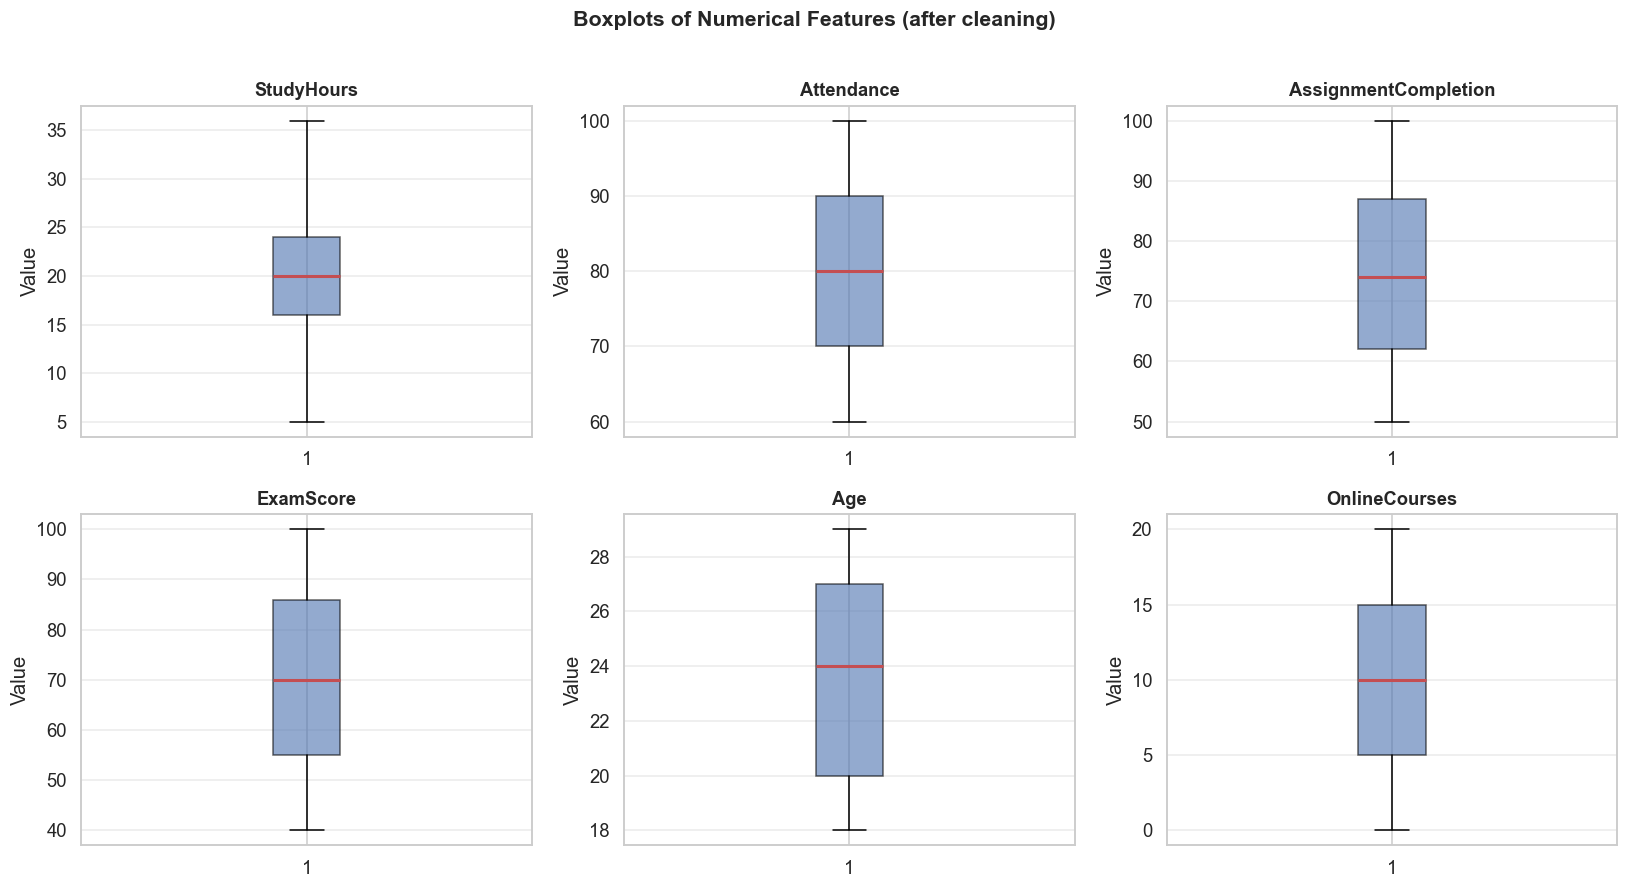

✅ Boxplots rendered. Inspect for any remaining extreme outliers.


In [28]:
# ── Boxplots for numerical feature distributions ──────────────────────────────
num_cols_plot = ["StudyHours", "Attendance", "AssignmentCompletion",
                 "ExamScore", "Age", "OnlineCourses"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    col_data = pd.to_numeric(df[col], errors="coerce")
    axes[i].boxplot(col_data.dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                    medianprops=dict(color="#C44E52", linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Value")
    axes[i].grid(axis="y", alpha=0.4)

plt.suptitle("Boxplots of Numerical Features (after cleaning)", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("✅ Boxplots rendered. Inspect for any remaining extreme outliers.")

### 6.4 Data Type Corrections

Ensuring each column has the correct data type:

- **Continuous numerical** columns → `int64` or `float64`
- **Ordinal / binary encoded** columns → `int8` (saves memory)

This step makes sure downstream normalization and clustering operate on properly typed data.


In [29]:
# ── Cast categorical/binary columns to int8 ───────────────────────────────────
INT8_COLS = [
    "Gender", "LearningStyle", "Internet", "EduTech",
    "Extracurricular", "Discussions", "Motivation",
    "StressLevel", "FinalGrade", "Resources",
]

for col in INT8_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("int8")

# ── Cast continuous columns to int64 ──────────────────────────────────────────
for col in CONTINUOUS_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("int64")

print("✅ Data types after correction:")
print(df.dtypes.to_string())

✅ Data types after correction:
StudyHours              int64
Attendance              int64
Resources                int8
Extracurricular          int8
Motivation               int8
Internet                 int8
Gender                   int8
Age                     int64
LearningStyle            int8
OnlineCourses           int64
Discussions              int8
AssignmentCompletion    int64
ExamScore               int64
EduTech                  int8
StressLevel              int8
FinalGrade               int8


### 6.5 Normalization

Clustering algorithms like K-Means are **sensitive to scale**. A column with values from 0–100 will dominate one with values from 0–3 unless we normalize.

We apply **Min-Max Scaling** to the continuous numerical columns, transforming each value to the range **[0, 1]**:

$$x_{\\text{norm}} = \\frac{x - x_{\\min}}{x_{\\max} - x_{\\min}}$$

- Ordinal / binary columns (0/1 or 0–3 ranges) are **left as-is** because they are already on a comparable small scale.
- The **original columns are preserved**; normalized values are stored in new `_norm` columns so the raw data is never lost.

> The normalized columns will be used by the clustering notebooks. The original columns remain available for interpretation.


In [30]:

# ── Min-Max Normalization (Direct Replacement) ────────────────────────────────
scaler = MinMaxScaler()

# Target columns
COLS_TO_NORMALIZE = ["StudyHours", "Attendance", "AssignmentCompletion", 
                     "ExamScore", "Age", "OnlineCourses"]

# Overwrite the original columns directly
df[COLS_TO_NORMALIZE] = scaler.fit_transform(df[COLS_TO_NORMALIZE])

# Round to 4 decimal places for a cleaner CSV file
df[COLS_TO_NORMALIZE] = df[COLS_TO_NORMALIZE].round(4)

print("✅ Normalization complete. Original continuous columns replaced with [0, 1] values.")
print(df[COLS_TO_NORMALIZE].head())

✅ Normalization complete. Original continuous columns replaced with [0, 1] values.
   StudyHours  Attendance  AssignmentCompletion  ExamScore  Age  OnlineCourses
0        0.45        0.10                  0.18       0.00 0.09           0.40
1        0.45        0.10                  0.80       0.43 0.45           0.80
2        0.45        0.10                  0.34       0.98 0.91           0.95
3        0.45        0.10                  0.18       0.00 0.09           0.40
4        0.45        0.10                  0.80       0.43 0.45           0.80


---
## 7. Saving the Cleaned Dataset

The cleaned and normalized dataset is saved to `Data/processed/cleaned_dataset.csv`. This file is the **official input** for all downstream notebooks (EDA, feature engineering, clustering, evaluation).

> **Note:** Feature engineering (creating composite scores, etc.) is handled by **Member 2 (EDA & Feature Specialist)**. This notebook focuses only on cleaning and normalization.


In [31]:
# ── Final inspection ──────────────────────────────────────────────────────────
print(f"📌 Final Cleaned Dataset Shape: {df.shape}")
print("📌 Columns included:", df.columns.tolist())

# ── Save ──────────────────────────────────────────────────────────────────────
# This will now save the version where StudyHours, Age, etc., are already normalized
df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"\n✅ Processed dataset (normalized only) saved to: {PROCESSED_DATA_PATH}")

📌 Final Cleaned Dataset Shape: (12469, 16)
📌 Columns included: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

✅ Processed dataset (normalized only) saved to: ..\Data\processed\cleaned_dataset.csv


In [32]:
# ── Quick verification: reload and check ─────────────────────────────────────
df_check = pd.read_csv(PROCESSED_DATA_PATH)
print(f"✅ Verification — reloaded file shape: {df_check.shape}")
df_check.head()

✅ Verification — reloaded file shape: (12469, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,0.45,0.10,1,0,0,1,0,0.09,2,0.40,1,0.18,0.00,0,1,3
1,0.45,0.10,1,0,0,1,0,0.45,3,0.80,0,0.80,0.43,0,1,2
2,0.45,0.10,1,0,0,1,0,0.91,1,0.95,0,0.34,0.98,1,1,0
3,0.45,0.10,1,1,0,1,0,0.09,2,0.40,1,0.18,0.00,0,1,3
4,0.45,0.10,1,1,0,1,0,0.45,3,0.80,0,0.80,0.43,0,1,2


---
## 8. Summary & Handoff Notes

### ✅ What Was Accomplished (Member 1 — Data Engineer)

| Task | Status | Details |
|------|--------|----------|
| Dataset loaded | ✅ | 14,003 rows × 16 columns |
| Initial inspection | ✅ | Shape, dtypes, and first rows verified |
| Missing values handled | ✅ | No missing values found; imputation logic in place |
| Duplicates removed | ✅ | 1,534 duplicate rows removed → 12,469 clean rows |
| Range validation | ✅ | All values verified within expected ranges |
| Outlier handling | ✅ | IQR method applied; values clipped where needed |
| Data type corrections | ✅ | Continuous cols → int64, categoricals → int8 |
| Normalization | ✅ | Min-Max scaling applied to 6 continuous columns |
| Processed file saved | ✅ | `Data/processed/cleaned_dataset.csv` |


---
